# Phan tich dataCleand.csv

Notebook nay doc file du lieu da lam sach va ve bieu do doanh thu, loi nhuan theo danh muc san pham.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Doc file CSV
df = pd.read_csv(
    'dataCleand.csv',
    encoding='utf-8-sig',
    parse_dates=['Order Date', 'Ship Date']
)

print(f'So dong: {df.shape[0]:,}')
print(f'So cot: {df.shape[1]}')
df.head()

So dong: 9,994
So cot: 21


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,2013-11-09,2013-11-12,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,2013-06-13,2013-06-17,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,2012-10-11,2012-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
# Cac bang tong hop dung cho phan tich
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = total_profit / total_sales * 100

category_summary = (df.groupby('Category', as_index=False)
                    .agg(Doanh_thu=('Sales', 'sum'), Loi_nhuan=('Profit', 'sum'))
                    .assign(Bien_loi_nhuan=lambda x: x['Loi_nhuan'] / x['Doanh_thu'] * 100)
                    .sort_values('Doanh_thu', ascending=False))

region_summary = (df.groupby('Region', as_index=False)
                  .agg(Doanh_thu=('Sales', 'sum'), Loi_nhuan=('Profit', 'sum'))
                  .sort_values('Loi_nhuan', ascending=False))

sub_category_profit = (df.groupby('Sub-Category', as_index=False)['Profit'].sum()
                       .sort_values('Profit'))

monthly_summary = (df.set_index('Order Date').resample('ME')
                   .agg(Doanh_thu=('Sales', 'sum'), Loi_nhuan=('Profit', 'sum'))
                   .reset_index())

print(f'Tong doanh thu: ${total_sales:,.0f}')
print(f'Tong loi nhuan: ${total_profit:,.0f}')
print(f'Bien loi nhuan: {profit_margin:.2f}%')
print(f'Danh muc doanh thu cao nhat: {category_summary.iloc[0]["Category"]}')
print(f'Khu vuc loi nhuan cao nhat: {region_summary.iloc[0]["Region"]}')
print(f'Nhom san pham loi nhuan thap nhat: {sub_category_profit.iloc[0]["Sub-Category"]}')

display(category_summary.style.format({'Doanh_thu': '${:,.0f}', 'Loi_nhuan': '${:,.0f}', 'Bien_loi_nhuan': '{:.2f}%'}))

Tong doanh thu: $2,297,201
Tong loi nhuan: $286,397
Bien loi nhuan: 12.47%
Danh muc doanh thu cao nhat: Technology
Khu vuc loi nhuan cao nhat: West
Nhom san pham loi nhuan thap nhat: Tables


,Category,Doanh_thu,Loi_nhuan,Bien_loi_nhuan
2,Technology,"$836,154","$145,455",17.40%
0,Furniture,"$742,000","$18,451",2.49%
1,Office Supplies,"$719,047","$122,491",17.04%


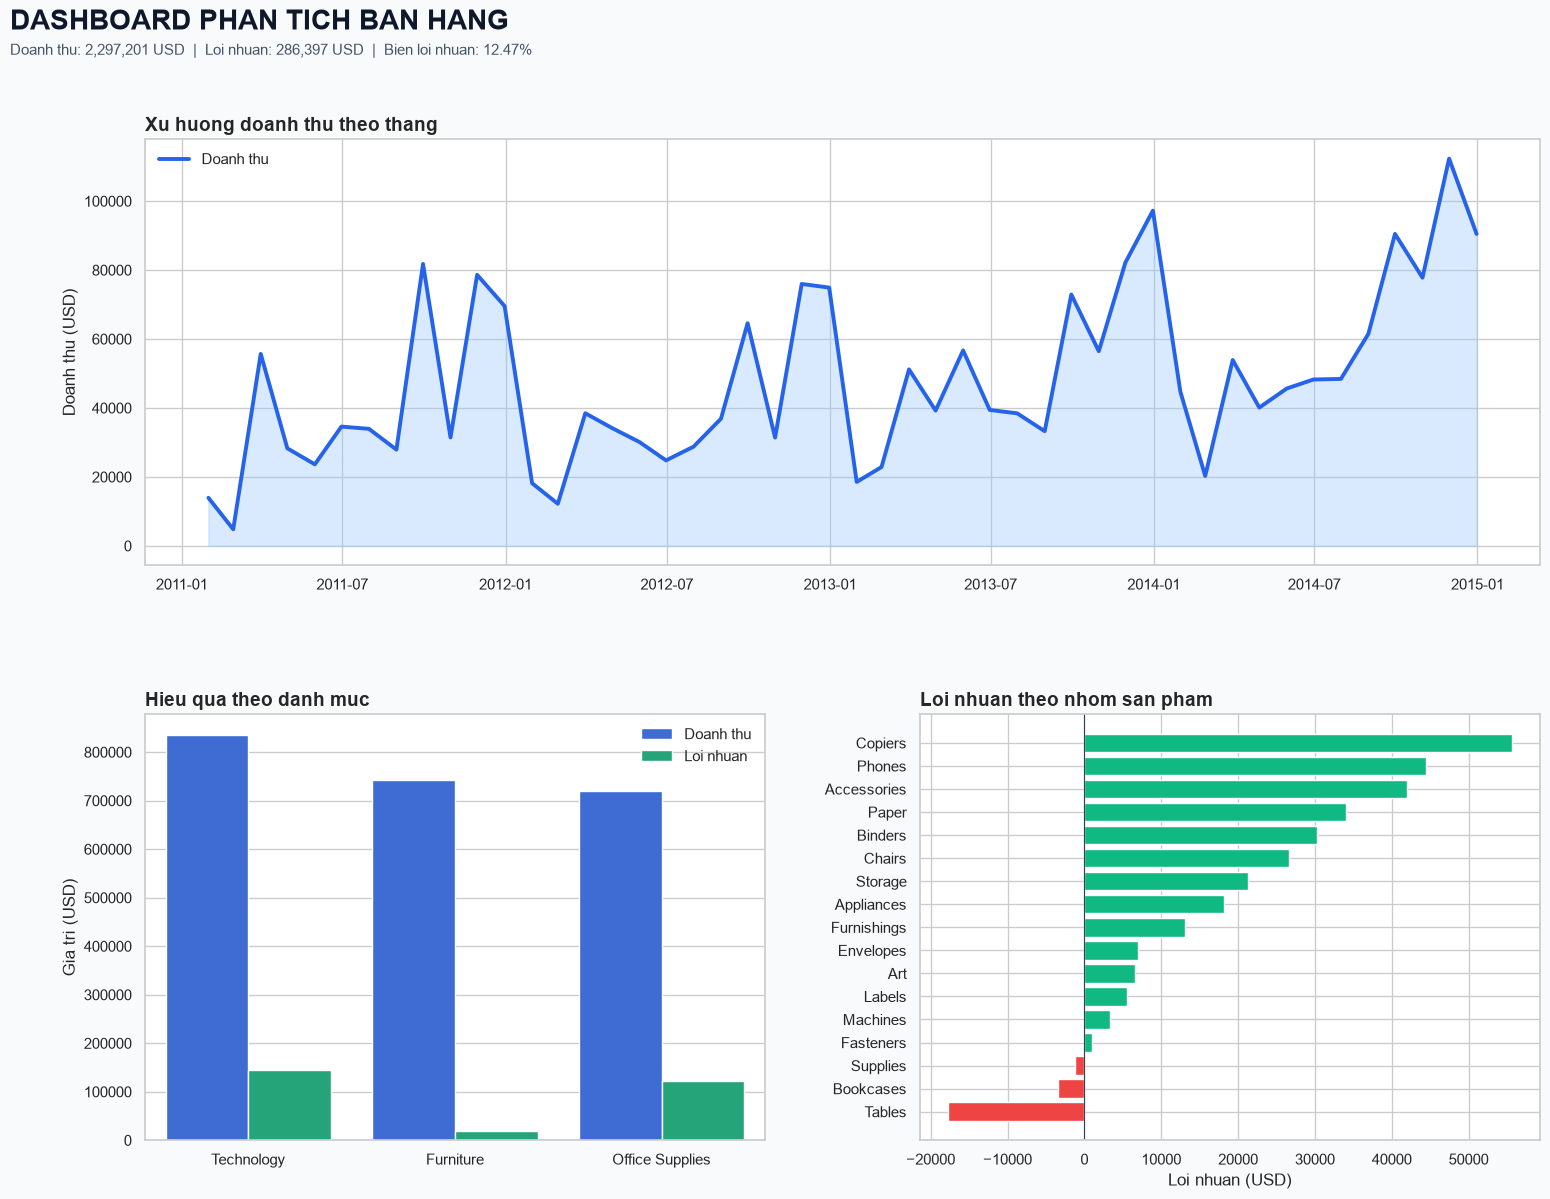

Da luu anh: dashboard_phan_tich_data_cleand.png


In [3]:
# Dashboard va luu anh phan tich
sns.set_theme(style='whitegrid', context='notebook')
fig = plt.figure(figsize=(18, 13), facecolor='#F8FAFC')
grid = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.25)

# 1. Xu huong doanh thu va loi nhuan theo thang
ax1 = fig.add_subplot(grid[0, :])
ax1.plot(monthly_summary['Order Date'], monthly_summary['Doanh_thu'], color='#2563EB', linewidth=2.8, label='Doanh thu')
ax1.fill_between(monthly_summary['Order Date'], monthly_summary['Doanh_thu'], color='#93C5FD', alpha=0.35)
ax1.set_title('Xu huong doanh thu theo thang', loc='left', fontsize=14, fontweight='bold')
ax1.set_ylabel('Doanh thu (USD)')
ax1.ticklabel_format(style='plain', axis='y')
ax1.legend(frameon=False, loc='upper left')

# 2. Doanh thu va loi nhuan theo danh muc
ax2 = fig.add_subplot(grid[1, 0])
category_long = category_summary.melt(id_vars='Category', value_vars=['Doanh_thu', 'Loi_nhuan'],
                                    var_name='Chi so', value_name='Gia tri')
category_long['Chi so'] = category_long['Chi so'].map({'Doanh_thu': 'Doanh thu', 'Loi_nhuan': 'Loi nhuan'})
sns.barplot(data=category_long, x='Category', y='Gia tri', hue='Chi so',
            palette=['#2563EB', '#10B981'], ax=ax2)
ax2.set_title('Hieu qua theo danh muc', loc='left', fontsize=14, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Gia tri (USD)')
ax2.ticklabel_format(style='plain', axis='y')
ax2.legend(title='', frameon=False)

# 3. Loi nhuan cua cac nhom san pham
ax3 = fig.add_subplot(grid[1, 1])
bar_colors = ['#EF4444' if x < 0 else '#10B981' for x in sub_category_profit['Profit']]
ax3.barh(sub_category_profit['Sub-Category'], sub_category_profit['Profit'], color=bar_colors)
ax3.axvline(0, color='#334155', linewidth=0.8)
ax3.set_title('Loi nhuan theo nhom san pham', loc='left', fontsize=14, fontweight='bold')
ax3.set_xlabel('Loi nhuan (USD)')
ax3.ticklabel_format(style='plain', axis='x')

fig.suptitle('DASHBOARD PHAN TICH BAN HANG', x=0.05, y=0.98, ha='left', fontsize=20, fontweight='bold', color='#0F172A')
fig.text(0.05, 0.945, f'Doanh thu: {total_sales:,.0f} USD  |  Loi nhuan: {total_profit:,.0f} USD  |  Bien loi nhuan: {profit_margin:.2f}%',
         fontsize=11, color='#475569')

output_file = 'dashboard_phan_tich_data_cleand.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'Da luu anh: {output_file}')

In [4]:
# Phan tich chi tiet va cac diem can chu y
region_analysis = region_summary.assign(Bien_loi_nhuan=lambda x: x['Loi_nhuan'] / x['Doanh_thu'] * 100)
loss_making = sub_category_profit.query('Profit < 0')

print('CAC KET LUAN CHINH')
print(f'1. Technology dan dau ve doanh thu (${category_summary.iloc[0]["Doanh_thu"]:,.0f}) va loi nhuan.')
print(f'2. Furniture co doanh thu cao, nhung bien loi nhuan chi {category_summary.loc[category_summary["Category"] == "Furniture", "Bien_loi_nhuan"].iloc[0]:.2f}%.')
print(f'3. {region_analysis.iloc[0]["Region"]} la khu vuc co loi nhuan cao nhat.')
print('4. Can xem lai gia ban, chiet khau va chi phi cua cac nhom dang lo: ' + ', '.join(loss_making['Sub-Category']) + '.')

print('\nHIEU QUA THEO KHU VUC')
display(region_analysis.style.format({'Doanh_thu': '${:,.0f}', 'Loi_nhuan': '${:,.0f}', 'Bien_loi_nhuan': '{:.2f}%'}))

print('NHOM SAN PHAM CO LOI NHUAN AM')
display(loss_making.style.format({'Profit': '${:,.0f}'}))

CAC KET LUAN CHINH
1. Technology dan dau ve doanh thu ($836,154) va loi nhuan.
2. Furniture co doanh thu cao, nhung bien loi nhuan chi 2.49%.
3. West la khu vuc co loi nhuan cao nhat.
4. Can xem lai gia ban, chiet khau va chi phi cua cac nhom dang lo: Tables, Bookcases, Supplies.

HIEU QUA THEO KHU VUC


,Region,Doanh_thu,Loi_nhuan,Bien_loi_nhuan
3,West,"$725,458","$108,418",14.94%
1,East,"$678,781","$91,523",13.48%
2,South,"$391,722","$46,749",11.93%
0,Central,"$501,240","$39,706",7.92%


NHOM SAN PHAM CO LOI NHUAN AM


,Sub-Category,Profit
16,Tables,"$-17,725"
4,Bookcases,"$-3,473"
15,Supplies,"$-1,189"
